<a href="https://colab.research.google.com/github/puchit2903-design/SocialWebAnalytics_Puchit/blob/main/Trustpilot_Topic_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 5: Topic Modelling (LDA + BERTopic)

## Purpose
Discover recurring **complaint themes** in KFC Trustpilot negative reviews.

## Models
| Model | How it works | Strengths |
|---|---|---|
| **LDA** | Frequency-based (Bag-of-Words) | Broad, interpretable themes |
| **BERTopic** | Embedding-based (sentence-transformers + clustering) | Better with varied review lengths |

## Input
`kfc_tp_negative_reviews.csv` (from Notebook 4)

## Output
- `lda_topics.csv`, `bertopic_themes.csv`, `topic_comparison.csv`, `lda_coherence_plot.png`

## Step 0 - Import Libraries

In [1]:
!pip install pandas numpy gensim bertopic scikit-learn matplotlib
!pip install sentence-transformers umap-learn hdbscan

import pandas as pd
import numpy as np
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from bertopic import BERTopic
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
print("Libraries loaded.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Libraries loaded.


## Step 1 - Load Data

In [3]:
df = pd.read_csv("kfc_tp_negative_reviews.csv")
print(f"Loaded {len(df)} negative reviews")

documents = df["Tokenised_Review"].tolist()
tokenised_docs = [doc.split() for doc in documents]

Loaded 139 negative reviews


---
# Part A: LDA

## Step 2 - Build BoW Corpus

In [4]:
dictionary = corpora.Dictionary(tokenised_docs)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in tokenised_docs]
print(f"Dictionary: {len(dictionary)} tokens | Corpus: {len(corpus)} docs")

Dictionary: 140 tokens | Corpus: 139 docs


## Step 3 - Find Optimal Topics (Coherence)

In [5]:
print("Testing LDA with 2-10 topics...")
topic_range = range(2, 11)
scores = []
for n in topic_range:
    m = LdaModel(corpus=corpus, id2word=dictionary, num_topics=n,
                 random_state=42, passes=15, alpha="auto", eta="auto")
    cm = CoherenceModel(model=m, texts=tokenised_docs, dictionary=dictionary, coherence="c_v")
    s = cm.get_coherence()
    scores.append(s)
    print(f"  Topics={n:2d}  Coherence={s:.4f}")

best_idx = np.argmax(scores)
best_n = list(topic_range)[best_idx]
best_coh = scores[best_idx]
print(f"\nBest: {best_n} topics (coherence = {best_coh:.4f})")

Testing LDA with 2-10 topics...
  Topics= 2  Coherence=0.2264
  Topics= 3  Coherence=0.3770
  Topics= 4  Coherence=0.3565
  Topics= 5  Coherence=0.3744
  Topics= 6  Coherence=0.3521
  Topics= 7  Coherence=0.3157
  Topics= 8  Coherence=0.3298
  Topics= 9  Coherence=0.3178
  Topics=10  Coherence=0.3384

Best: 3 topics (coherence = 0.3770)


## Step 4 - Coherence Plot

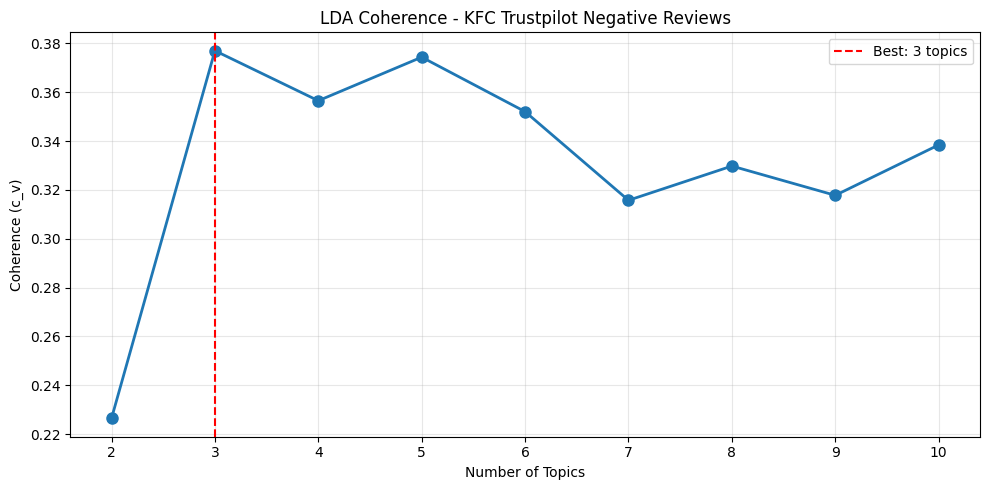

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(list(topic_range), scores, "o-", linewidth=2, markersize=8)
plt.axvline(x=best_n, color="red", linestyle="--", label=f"Best: {best_n} topics")
plt.xlabel("Number of Topics"); plt.ylabel("Coherence (c_v)")
plt.title("LDA Coherence - KFC Trustpilot Negative Reviews")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("lda_coherence_plot.png", dpi=150)
plt.show()

## Step 5 - Final LDA Model

In [7]:
final_lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=best_n,
                     random_state=42, passes=20, alpha="auto", eta="auto")

lda_data = []
print(f"LDA Topics (top 10 keywords):")
for i in range(best_n):
    kw = [w for w, _ in final_lda.show_topic(i, topn=10)]
    print(f"  Topic {i}: {', '.join(kw)}")
    lda_data.append({"Topic": i, "Top Keywords": ", ".join(kw)})

pd.DataFrame(lda_data).to_csv("lda_topics.csv", index=False)

all_w = [w for i in range(best_n) for w, _ in final_lda.show_topic(i, topn=10)]
lda_div = len(set(all_w)) / len(all_w)
print(f"\nLDA Diversity: {lda_div:.3f}")

LDA Topics (top 10 keywords):
  Topic 0: chicken, piece, two, wing, box, bucket, fillet, burger, disappointing, good
  Topic 1: chicken, burger, chip, cold, fry, drink, never, give, taste, small
  Topic 2: chip, told, asked, refund, money, tried, manager, wasnt, away, absolutely

LDA Diversity: 0.900


---
# Part B: BERTopic

## Step 6 - Train BERTopic

In [12]:
print("Training BERTopic...")
raw_docs = df["Tokenised_Review"].tolist()

topic_model = BERTopic(language="english", min_topic_size=10,
                       nr_topics="auto", verbose=True)
topics, probs = topic_model.fit_transform(raw_docs)
print("Done.")

2026-03-28 13:45:05,985 - BERTopic - Embedding - Transforming documents to embeddings.


Training BERTopic...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

2026-03-28 13:45:12,809 - BERTopic - Embedding - Completed ✓
2026-03-28 13:45:12,811 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-28 13:45:13,034 - BERTopic - Dimensionality - Completed ✓
2026-03-28 13:45:13,036 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-28 13:45:13,048 - BERTopic - Cluster - Completed ✓
2026-03-28 13:45:13,049 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-28 13:45:13,070 - BERTopic - Representation - Completed ✓
2026-03-28 13:45:13,071 - BERTopic - Topic reduction - Reducing number of topics
2026-03-28 13:45:13,080 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-28 13:45:13,095 - BERTopic - Representation - Completed ✓
2026-03-28 13:45:13,097 - BERTopic - Topic reduction - Reduced number of topics from 3 to 3


Done.


## Step 7 - Extract Results

In [13]:
topic_info = topic_model.get_topic_info()
n_topics = len(topic_info) - 1

bert_data = []
print(f"BERTopic found {n_topics} topics:")
for _, row in topic_info[topic_info["Topic"] != -1].iterrows():
    tid = row["Topic"]
    kw = [w for w, _ in topic_model.get_topic(tid)[:10]]
    print(f"  Topic {tid}: {', '.join(kw)}")
    bert_data.append({"Topic": tid, "Count": row["Count"],
                      "Top Keywords": ", ".join(kw), "Interpreted Theme": ""})

pd.DataFrame(bert_data).to_csv("bertopic_themes.csv", index=False)
print("\nSaved: bertopic_themes.csv")

BERTopic found 2 topics:
  Topic 0: chicken, chip, burger, cold, piece, fry, drink, fillet, box, bucket
  Topic 1: refund, complaint, tried, money, right, address, hour, manager, consumer, voucher

Saved: bertopic_themes.csv


## Step 8 - Coherence & Diversity

In [14]:
all_bw, tw_lists = [], []
for _, row in topic_info[topic_info["Topic"] != -1].iterrows():
    kw = [w for w, _ in topic_model.get_topic(row["Topic"])[:10]]
    all_bw.extend(kw); tw_lists.append(kw)

bert_div = len(set(all_bw)) / len(all_bw) if all_bw else 0
try:
    bcm = CoherenceModel(topics=tw_lists, texts=tokenised_docs,
                         dictionary=dictionary, coherence="c_v")
    bert_coh = bcm.get_coherence()
    print(f"BERTopic Coherence: {bert_coh:.4f}")
except Exception as e:
    bert_coh = None
    print(f"Could not compute coherence: {e}")
print(f"BERTopic Diversity: {bert_div:.3f}")

BERTopic Coherence: 0.5150
BERTopic Diversity: 1.000


---
# Part C: Comparison

In [15]:
comp = pd.DataFrame({
    "Metric": ["Coherence", "Diversity", "Topics"],
    "LDA": [f"{best_coh:.3f}", f"{lda_div:.3f}", str(best_n)],
    "BERTopic": [f"{bert_coh:.3f}" if bert_coh else "N/A", f"{bert_div:.3f}", str(n_topics)],
})
print(comp.to_string(index=False))
comp.to_csv("topic_comparison.csv", index=False)
print("\nSaved: topic_comparison.csv")

   Metric   LDA BERTopic
Coherence 0.377    0.515
Diversity 0.900    1.000
   Topics     3        2

Saved: topic_comparison.csv


## Next Step

Open `bertopic_themes.csv` and fill in the **Interpreted Theme** column manually.